In [1]:
# Download HITRAN24 data from web #

from pathlib import Path
import h5py

# This is the directory where all files used by this notebook will be saved.
test_data_dir = Path("./test_data")

ans_pf_tabulated_database_file = test_data_dir / "hitran24_pf_tabulated.h5"
ans_pf_polynomial_database_file = test_data_dir / "hitran24_pf_poly.h5"

test_data_dir.mkdir(parents=True, exist_ok=True)




Polynomial and Tabulated partition functions do not agree for '/partition_function/C2H2/1'


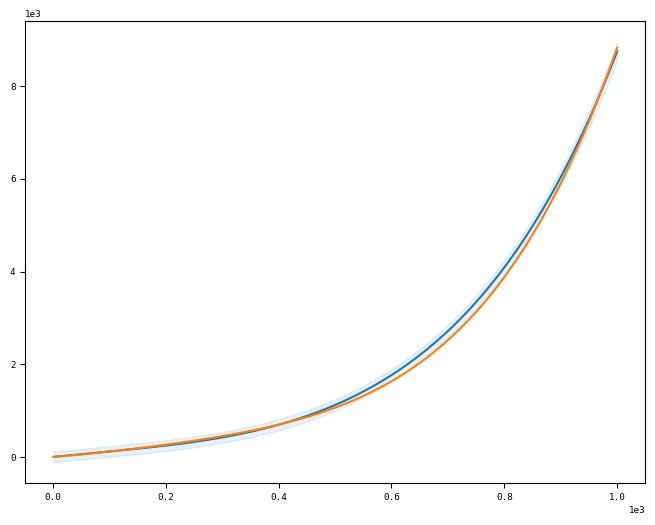

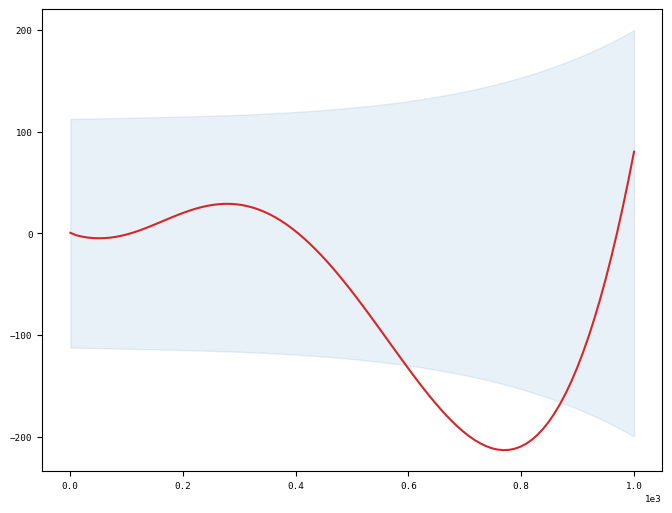

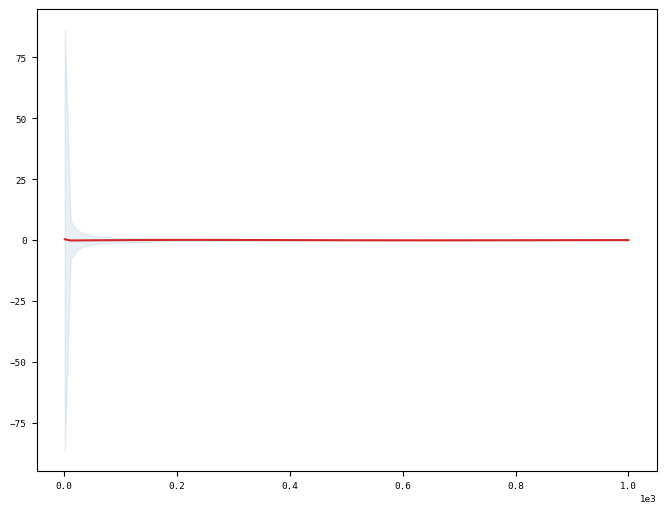

Polynomial and Tabulated partition functions do not agree for '/partition_function/C2H2/2'


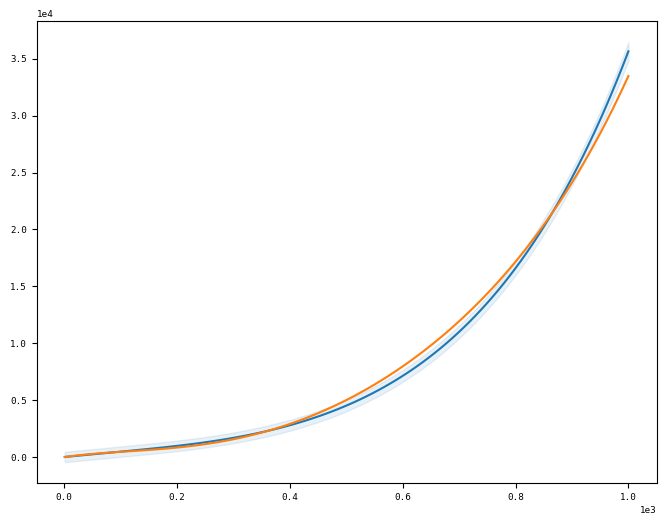

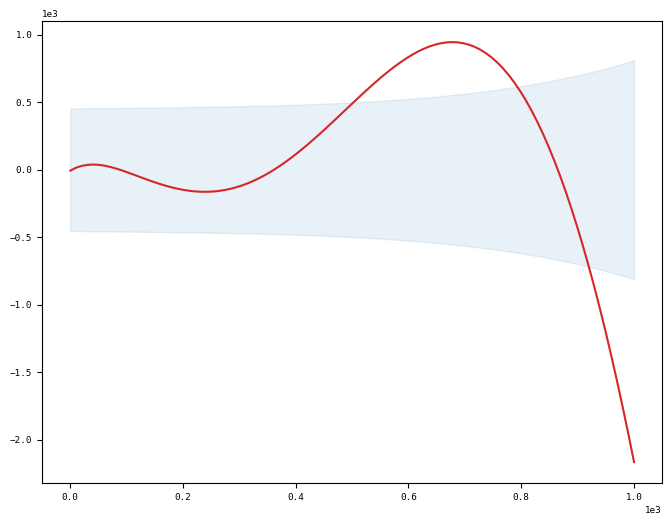

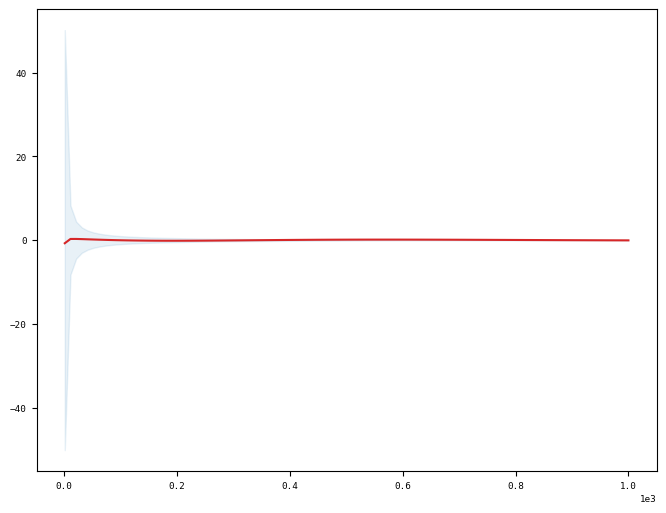

Polynomial and Tabulated partition functions do not agree for '/partition_function/C2H2/3'


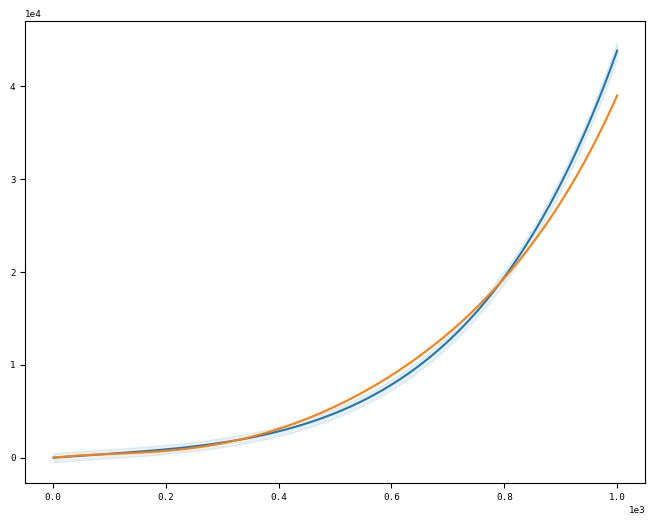

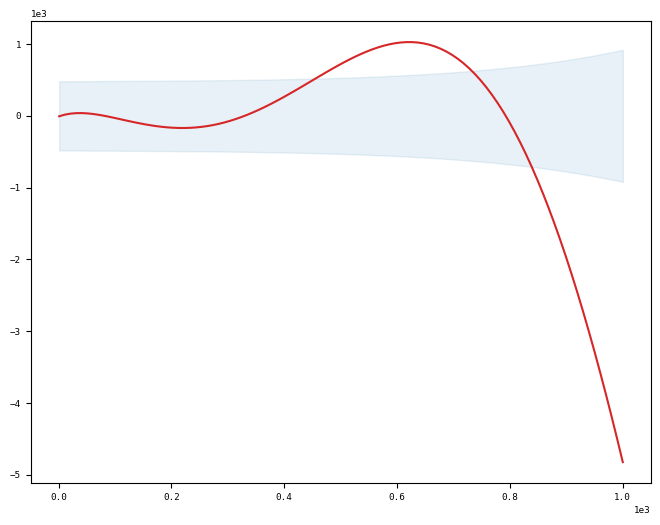

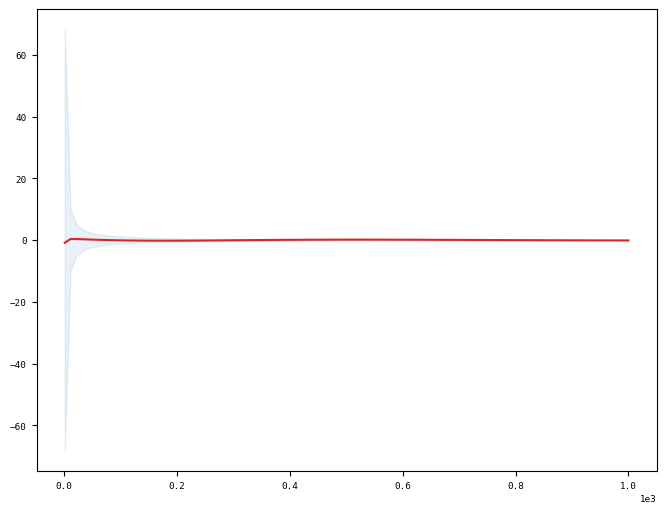

Polynomial and Tabulated partition functions do not agree for '/partition_function/C2H4/1'


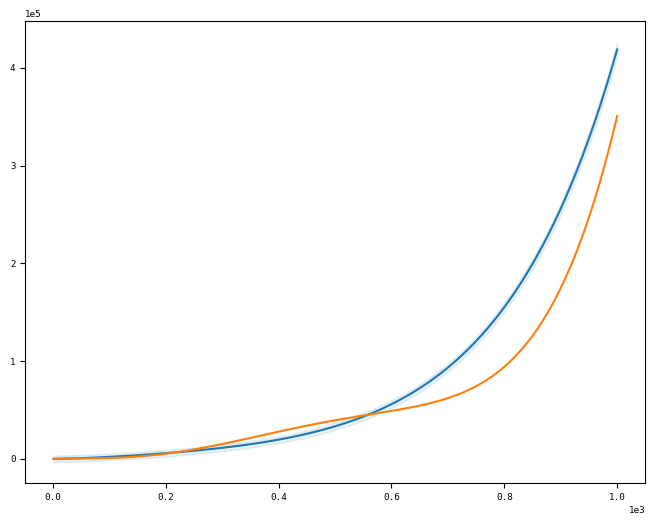

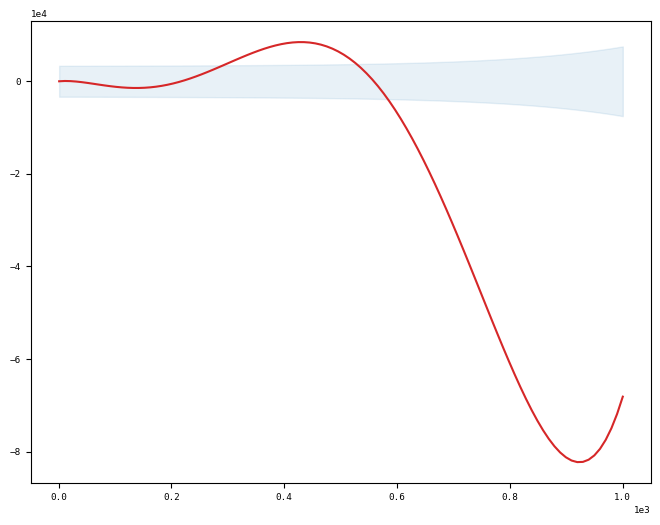

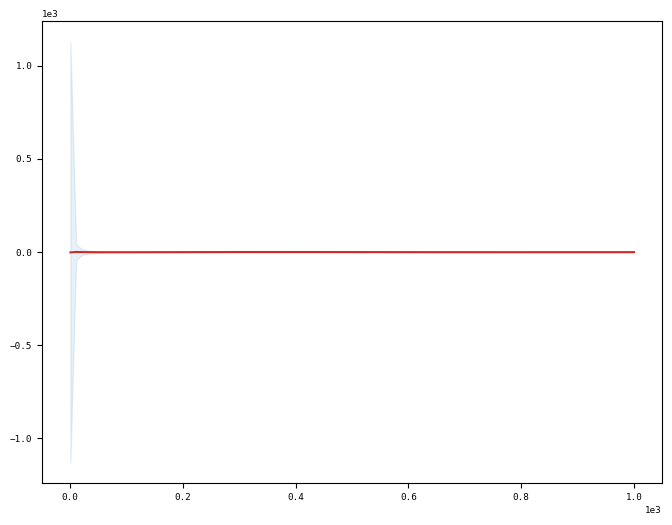

Polynomial and Tabulated partition functions do not agree for '/partition_function/C2H4/2'
Polynomial and Tabulated partition functions do not agree for '/partition_function/C2H6/1'
Polynomial and Tabulated partition functions do not agree for '/partition_function/C2H6/2'
Polynomial and Tabulated partition functions do not agree for '/partition_function/C2N2/1'
Polynomial and Tabulated partition functions do not agree for '/partition_function/C4H2/1'
Polynomial and Tabulated partition functions do not agree for '/partition_function/CF4/1'
Polynomial and Tabulated partition functions do not agree for '/partition_function/CH3/1'
Polynomial and Tabulated partition functions do not agree for '/partition_function/CH3Br/1'
Polynomial and Tabulated partition functions do not agree for '/partition_function/CH3Br/2'
Polynomial and Tabulated partition functions do not agree for '/partition_function/CH3CN/1'
Polynomial and Tabulated partition functions do not agree for '/partition_function/CH3Cl/

In [10]:
# tabulated and polynomial results should be identical
import numpy as np
import matplotlib.pyplot as plt

from archnemesis.database.filetypes.ans_partition_fn_data_file import AnsPartitionFunctionDataFile

hitran_pf_tabulated_data_file = AnsPartitionFunctionDataFile(ans_pf_tabulated_database_file)
hitran_pf_polynomial_data_file = AnsPartitionFunctionDataFile(ans_pf_polynomial_database_file)

n_max_plots = 4
n_plots = 0

t_grid = np.linspace(1,1000, 100)

for (tab_name, tab_grp), (poly_name, poly_grp) in zip(hitran_pf_tabulated_data_file.iter_iso_grps(), hitran_pf_polynomial_data_file.iter_iso_grps()):
	#print(f'{tab_grp.name=} {poly_grp.name=}')
	
	assert tab_grp.name == poly_grp.name, "Group names should be identical"
	
	tab_pf_data = hitran_pf_tabulated_data_file.get_data_from_iso_grp(tab_grp)
	
	poly_pf_data = hitran_pf_polynomial_data_file.get_data_from_iso_grp(poly_grp)
	

	tab_q = tab_pf_data(t_grid)
	poly_q = poly_pf_data(t_grid)
	
	residual = poly_q - tab_q
	
	tol = np.quantile(np.abs(tab_q), 0.5)*1E-1 + 1E-2*np.abs(tab_q)
	if np.any(np.abs(residual) > tol):
		print(f"Polynomial and Tabulated partition functions do not agree for '{tab_grp.name}'")
	
		if True and n_plots < n_max_plots:
			plt.figure()
			tt = plt.plot(t_grid, tab_q)
			plt.plot(t_grid, poly_q)
			plt.fill_between(t_grid, tab_q - tol, tab_q + tol, color=tt[0].get_color(), alpha=0.1)
			
			plt.figure()
			plt.plot(t_grid, residual, color='tab:red')
			plt.fill_between(t_grid, -1*tol, tol, color=tt[0].get_color(), alpha=0.1)
			
			plt.figure()
			plt.plot(t_grid, residual/tab_q, color='tab:red')
			plt.fill_between(t_grid, -1*tol/tab_q, tol/tab_q, color=tt[0].get_color(), alpha=0.1)
			
			plt.show()
			
			n_plots += 1
			
			
	
	
	
	
